In [1]:
import pandas as pd

portfolio = pd.read_csv("../data/portfolio.csv")
profile = pd.read_csv("../data/profile.csv")
transcript = pd.read_csv("../data/transcript.csv")


In [2]:
display(portfolio.head(5))
display(profile.head(5))
display(transcript.head(5))

,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


,Unnamed: 0,gender,age,id,became_member_on,income
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


,Unnamed: 0,person,event,value,time
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


# 데이터 전처리
- 결측치 처리
    - prf테이블 gender와 income에 2175개 존재
- 이상치 처리
    - age 118세 존재(2175개) / 전체적으로 높은 나이 분포
- 데이터 정제
    - became_member_on 컬럼 datetime으로 변환
    - channels 에서 각각 web, email, mobile, social로 나눌 것인가
- 데이터 파생 변수
    - value 컬럼의 딕셔너리 형태 값을 offer id, offer id + reward, amount로 나눠 파생 변수 생성


In [ ]:
# 데이터 타입 date형식으로 변환
profile["became_member_on"] = pd.to_datetime(profile["became_member_on"], format="%Y%m%d")

In [ ]:
# channels마다 파생변수 생성
portfolio['web'] = portfolio['channels'].astype(str).str.contains('web').astype(int)
portfolio['email'] = portfolio['channels'].astype(str).str.contains('email').astype(int)
portfolio['mobile'] = portfolio['channels'].astype(str).str.contains('mobile').astype(int)
portfolio['social'] = portfolio['channels'].astype(str).str.contains('social').astype(int)

# 2. 다 쓴 원래 컬럼은 버립니다.
portfolio = portfolio.drop('channels', axis=1)

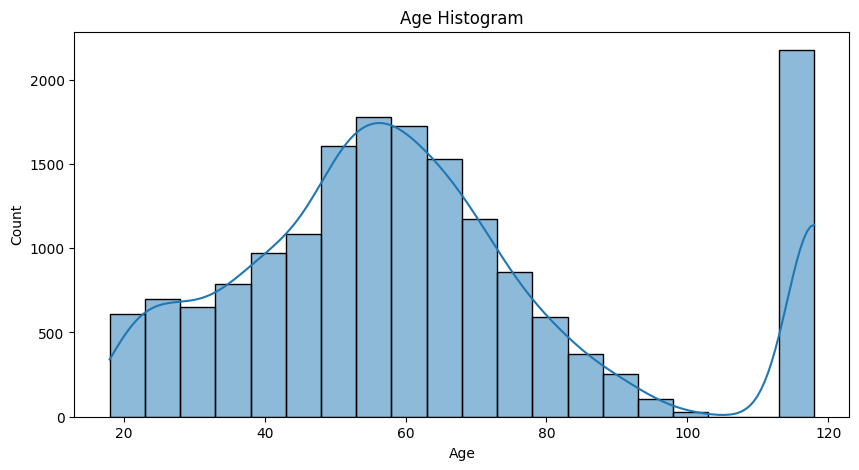

In [8]:
# age 분포 히스토그램
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(data=profile, x='age', bins=20, kde=True)

plt.title('Age Histogram')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


In [9]:
# age가 118인 행의 gender와 income은 모두 NaN일까?
age_118 = profile[profile["age"] == 118]

display(age_118.head())
print("gender가 모두 결측치인가?", age_118["gender"].isna().all())
print("income가 모두 결측치인가?", age_118["income"].isna().all())


,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,2017-02-12,NaN
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,2018-07-12,NaN
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,2017-08-04,NaN
6,NaN,118,8ec6ce2a7e7949b1bf142def7d0e0586,2017-09-25,NaN
7,NaN,118,68617ca6246f4fbc85e91a2a49552598,2017-10-02,NaN


gender가 모두 결측치인가? True
income가 모두 결측치인가? True


In [10]:
import pandas as pd
import ast

# 1. 딕셔너리처럼 생긴 문자열을 진짜 딕셔너리로 변환
transcript['value'] = transcript['value'].apply(ast.literal_eval)

# 2. 딕셔너리의 키 들을 새로운 컬럼으로 전개
value_df = pd.DataFrame(transcript['value'].tolist())

# 3. transcipt테이블에 이어 붙임
transcript = pd.concat([transcript, value_df], axis=1)

# 4. offer id를 offer_id로 컬럼명 통일
transcript['offer_id'] = transcript['offer_id'].fillna(transcript['offer id'])

# 5. offer id 컬럼은 제거
transcript = transcript.drop('offer id', axis=1)

In [11]:
transcript.head()

,person,event,value,time,amount,offer_id,reward
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN


In [ ]:
# transcript 기준으로 profile 데이터를 Left Join
merged_df = pd.merge(transcript, profile, left_on='person', right_on='id', how='left')

# 필요 없는 id 컬럼(person과 중복)은 버리기
merged_df = merged_df.drop(columns='id')

In [13]:
display(merged_df.head())
display(merged_df.shape)

,person,event,value,time,amount,offer_id,reward,gender,age,became_member_on,income
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,F,75,2017-05-09,100000.0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,118,2017-08-04,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,M,68,2018-04-26,70000.0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,118,2017-09-25,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,118,2017-10-02,NaN


(306534, 11)

In [14]:
# hyeong uk님의 논리를 그대로 번역한 필터링 조건
is_118_years_old = merged_df['age'] == 118
is_transaction = merged_df['event'] == 'transaction'

# 두 조건을 모두 만족하는 교집합 데이터만 뽑아내기
anomaly_transactions = merged_df[is_118_years_old & is_transaction]

# 수상한 고객들이 긁은 총 결제 횟수와 누적 금액 확인
total_count = anomaly_transactions['amount'].count()
total_spent = anomaly_transactions['amount'].sum()

print(f"118세 고객들의 총 결제 횟수: {total_count:,}건")
print(f"118세 고객들의 총 결제 금액: ${total_spent:,.2f}")

118세 고객들의 총 결제 횟수: 14,996건
118세 고객들의 총 결제 금액: $40,509.57


In [15]:
# merge_df에 대해서 수정하는게 맞는듯?

import numpy as np

# 1. gender의 빈칸을 'Unknown'으로 채우기 
merged_df['gender'] = merged_df['gender'].fillna('Unknown')

# 2. age의 118을 진짜 빈칸(NaN)으로 바꿔주기 
merged_df['age'] = merged_df['age'].replace(118, np.nan)

# 3. income은 이미 결측치(NaN) 상태로 비어있기 때문에 아무것도 안 해도 됨

In [16]:
# gender 필터링
is_gender_others = merged_df['gender'] == 'O'

# 두 조건을 모두 만족하는 교집합 데이터만 뽑아내기
anomaly_transactions2 = merged_df[is_gender_others & is_transaction]

# 수상한 고객들이 긁은 총 결제 횟수와 누적 금액 확인
total_count2 = anomaly_transactions2['amount'].count()
total_spent2 = anomaly_transactions2['amount'].sum()

print(f"others 고객들의 총 결제 횟수: {total_count2:,}건")
print(f"others 고객들의 총 결제 금액: ${total_spent2:,.2f}")

others 고객들의 총 결제 횟수: 1,781건
others 고객들의 총 결제 금액: $26,356.54


In [17]:
# portfolio 테이블도 병합 가능할듯?
all_merge_df = pd.merge(
    merged_df,
    portfolio,
    left_on='offer_id',
    right_on='id',
    how='left'
)

all_merge_df = all_merge_df.drop(columns='id')


In [18]:
# reward열 컬럼 변경(명확하게)
all_merge_df = all_merge_df.rename(columns={
    "reward_x": "transcript_reward",
    "reward_y": "portfolio_reward"
})


In [19]:
# 병합 잘 되었는지 확인
display(all_merge_df.head())
display(all_merge_df.shape)
display(all_merge_df["offer_type"].value_counts(dropna=False))

,person,event,value,time,amount,offer_id,transcript_reward,gender,age,became_member_on,income,portfolio_reward,difficulty,duration,offer_type,web,email,mobile,social
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,F,75.0,2017-05-09,100000.0,5.0,5.0,7.0,bogo,1.0,1.0,1.0,0.0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,Unknown,NaN,2017-08-04,NaN,5.0,20.0,10.0,discount,1.0,1.0,0.0,0.0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,M,68.0,2018-04-26,70000.0,2.0,10.0,7.0,discount,1.0,1.0,1.0,0.0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,Unknown,NaN,2017-09-25,NaN,2.0,10.0,10.0,discount,1.0,1.0,1.0,1.0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,Unknown,NaN,2017-10-02,NaN,10.0,10.0,5.0,bogo,1.0,1.0,1.0,1.0


(306534, 19)

offer_type
NaN              138953
bogo              71617
discount          69898
informational     26066
Name: count, dtype: int64

In [20]:
# 사람(person)별로 먼저 묶고, 그 안에서 시간(time) 순서대로 오름차순 정렬!
all_merge_df = all_merge_df.sort_values(by=['person', 'time'])

In [21]:
all_merge_df.head(30)

,person,event,value,time,amount,offer_id,transcript_reward,gender,age,became_member_on,income,portfolio_reward,difficulty,duration,offer_type,web,email,mobile,social
55972,0009655768c64bdeb2e877511632db8f,offer received,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},168,NaN,5a8bc65990b245e5a138643cd4eb9837,NaN,M,33.0,2017-04-21,72000.0,0.0,0.0,3.0,informational,0.0,1.0,1.0,1.0
77705,0009655768c64bdeb2e877511632db8f,offer viewed,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},192,NaN,5a8bc65990b245e5a138643cd4eb9837,NaN,M,33.0,2017-04-21,72000.0,0.0,0.0,3.0,informational,0.0,1.0,1.0,1.0
89291,0009655768c64bdeb2e877511632db8f,transaction,{'amount': 22.16},228,22.16,NaN,NaN,M,33.0,2017-04-21,72000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113605,0009655768c64bdeb2e877511632db8f,offer received,{'offer id': '3f207df678b143eea3cee63160fa8bed'},336,NaN,3f207df678b143eea3cee63160fa8bed,NaN,M,33.0,2017-04-21,72000.0,0.0,0.0,4.0,informational,1.0,1.0,1.0,0.0
139992,0009655768c64bdeb2e877511632db8f,offer viewed,{'offer id': '3f207df678b143eea3cee63160fa8bed'},372,NaN,3f207df678b143eea3cee63160fa8bed,NaN,M,33.0,2017-04-21,72000.0,0.0,0.0,4.0,informational,1.0,1.0,1.0,0.0
153401,0009655768c64bdeb2e877511632db8f,offer received,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},408,NaN,f19421c1d4aa40978ebb69ca19b0e20d,NaN,M,33.0,2017-04-21,72000.0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0
168412,0009655768c64bdeb2e877511632db8f,transaction,{'amount': 8.57},414,8.57,NaN,NaN,M,33.0,2017-04-21,72000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168413,0009655768c64bdeb2e877511632db8f,offer completed,{'offer_id': 'f19421c1d4aa40978ebb69ca19b0e20d...,414,NaN,f19421c1d4aa40978ebb69ca19b0e20d,5.0,M,33.0,2017-04-21,72000.0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0
187554,0009655768c64bdeb2e877511632db8f,offer viewed,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},456,NaN,f19421c1d4aa40978ebb69ca19b0e20d,NaN,M,33.0,2017-04-21,72000.0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0
204340,0009655768c64bdeb2e877511632db8f,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},504,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,M,33.0,2017-04-21,72000.0,2.0,10.0,10.0,discount,1.0,1.0,1.0,1.0


In [22]:
(all_merge_df['offer_type'] == 'informational').sum()

np.int64(26066)

In [23]:
# 무엇을 위해 하는 코드인가? -> informational이 아닌 completed와 amount 경우만 선택하는 과정

# 조건 1: 쿠폰 타입이 bogo 이거나(in) discount 인 것
cond_offers = all_merge_df['offer_type'].isin(['bogo', 'discount'])

# 조건 2: 이벤트 종류가 transaction(결제) 인 것
cond_transactions = all_merge_df['event'] == 'transaction'

# 위 두 조건 중 하나라도 만족하는(|) 데이터만 쏙 뽑아서 덮어씌우기
target_df = all_merge_df[cond_offers | cond_transactions].copy()

# 잘 걸러졌는지 눈으로 확인해보기
print(target_df['offer_type'].value_counts(dropna=False))
print(target_df['event'].value_counts(dropna=False))
display(target_df.head())
display(target_df.shape)

### 그냥 info인 event 행을 다 날리면 다른가?

offer_type
NaN         138953
bogo         71617
discount     69898
Name: count, dtype: int64
event
transaction        138953
offer received      61042
offer viewed        46894
offer completed     33579
Name: count, dtype: int64


,person,event,value,time,amount,offer_id,transcript_reward,gender,age,became_member_on,income,portfolio_reward,difficulty,duration,offer_type,web,email,mobile,social
89291,0009655768c64bdeb2e877511632db8f,transaction,{'amount': 22.16},228,22.16,NaN,NaN,M,33.0,2017-04-21,72000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153401,0009655768c64bdeb2e877511632db8f,offer received,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},408,NaN,f19421c1d4aa40978ebb69ca19b0e20d,NaN,M,33.0,2017-04-21,72000.0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0
168412,0009655768c64bdeb2e877511632db8f,transaction,{'amount': 8.57},414,8.57,NaN,NaN,M,33.0,2017-04-21,72000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168413,0009655768c64bdeb2e877511632db8f,offer completed,{'offer_id': 'f19421c1d4aa40978ebb69ca19b0e20d...,414,NaN,f19421c1d4aa40978ebb69ca19b0e20d,5.0,M,33.0,2017-04-21,72000.0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0
187554,0009655768c64bdeb2e877511632db8f,offer viewed,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},456,NaN,f19421c1d4aa40978ebb69ca19b0e20d,NaN,M,33.0,2017-04-21,72000.0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0


(280468, 19)

In [24]:
# person당 offer_id를 하나의 행으로 설정하여, 흩어진 고객 행동의 순서를 보기 편하게 해주는 "피벗테이블 생성 코드"

# 1. 피벗을 돌릴 '쿠폰 이력서' 데이터만 빼내기
offers_df = target_df[target_df['event'] != 'transaction'].copy()

# 2. 안전한 금고에 보관할 '순수 영수증' 데이터만 빼내기
transactions_df = target_df[target_df['event'] == 'transaction'].copy()

print(f"피벗할 쿠폰 데이터: {len(offers_df)} 줄")
print(f"금고에 보관한 영수증: {len(transactions_df)} 줄")

피벗할 쿠폰 데이터: 141515 줄
금고에 보관한 영수증: 138953 줄


In [25]:
# 시간 순으로 정렬 후, 사람&쿠폰별 첫 번째 이벤트만 쏙 뽑아오기
first_events = offers_df.sort_values(['person', 'offer_id', 'time']).groupby(['person', 'offer_id'])['event'].first()

# 그 첫 번째 이벤트가 'received'가 아닌 놈들(유령 데이터)만 필터링
ghost_data = first_events[first_events != 'offer received']

print(f"🚨 received 없이 시작하는 유령 세션 수: {len(ghost_data)}개")
if len(ghost_data) > 0:
    display(ghost_data.head())

🚨 received 없이 시작하는 유령 세션 수: 0개


In [26]:
# 1. 시간 순서대로 예쁘게 줄 세우기 (시간이 꼬이면 안 되니까 필수)
offers_df = offers_df.sort_values(['person', 'offer_id', 'time'])

# 2. 'received' 이벤트가 등장할 때마다 1, 아니면 0인 깃발(Flag) 만들기
offers_df['is_received'] = (offers_df['event'] == 'offer received').astype(int)

# 3. [마법의 함수] 사람과 쿠폰 단위로 묶어서, 깃발을 누적해서 더하기 (Cumsum)
offers_df['offer_cycle'] = offers_df.groupby(['person', 'offer_id'])['is_received'].cumsum()

# 4. 이제 찝찝함 없이 피벗 돌리기 (기준점에 offer_cycle 추가!)
pivot_df = offers_df.pivot_table(
    index=['person', 'offer_id', 'offer_cycle'],  # "누구의 / 어떤 쿠폰의 / 몇 회차인가?"
    columns='event',
    values='time',
    aggfunc='min'  # 이제 한 회차 안에는 중복이 없으니 min을 써도 아무 왜곡이 안 일어납니다 ### 이거 뭐임?
).reset_index()

# 깔끔하게 정리
pivot_df.columns.name = None
pivot_df = pivot_df[['person', 'offer_id', 'offer_cycle', 'offer received', 'offer viewed', 'offer completed']]

display(pivot_df.head())
display(pivot_df.shape)

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,1,576.0,NaN,576.0
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,1,408.0,456.0,414.0
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,1,504.0,540.0,528.0
3,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,1,168.0,216.0,NaN
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,2,576.0,630.0,NaN


(61042, 6)

In [27]:
# 1. 원본에서 offer_id와 offer_type 짝꿍 사전 만들기
offer_dict = offers_df[['offer_id', 'offer_type']].drop_duplicates().set_index('offer_id')['offer_type'].to_dict()

# 2. 피벗 테이블의 offer_id를 보고, 임시로 쿠폰 타입(bogo, discount)을 가져오기
temp_offer_type = pivot_df['offer_id'].map(offer_dict)

# 3. [핵심] 기존 숫자였던 'offer_cycle' 컬럼 위에 곧바로 덮어쓰기! 
pivot_df['offer_cycle'] = temp_offer_type.str.capitalize() + '_' + pivot_df['offer_cycle'].astype(str)

### offer_cycle 덮어 쓰지 않고 옆에 쿠폰 이름을 붙여 넣는 방식 등이 더 좋다

In [28]:
# 결과 확인
display(pivot_df.head())

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,Discount_1,576.0,NaN,576.0
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,Bogo_1,408.0,456.0,414.0
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,Discount_1,504.0,540.0,528.0
3,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,Bogo_1,168.0,216.0,NaN
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,Bogo_2,576.0,630.0,NaN


In [29]:
# 피벗테이블에 amount 붙이기

# 1. 금고(transactions_df)에서 영수증 알맹이만 꺼내기
transactions_df = transactions_df[['person', 'time', 'amount']]

# 2. 피벗 테이블(pivot_df)에 영수증(receipts) 1:1 도킹하기!
final_df = pivot_df.merge(
    transactions_df,
    left_on=['person', 'offer completed'],  # 왼쪽 표(피벗)의 도킹 기준: "누구의 / 언제 달성(completed)한 쿠폰인가?"
    right_on=['person', 'time'],      # 오른쪽 표(영수증)의 도킹 기준: "누가 / 언제(time) 결제했는가?"
    how='left'                        # 조인 방식: "피벗 표를 기준으로 하고, 영수증이 없으면 빈칸(NaN)으로 둬라!"
)

# 3. 도킹 끝나고 쓸모없어진 'time' 기둥 버리기
final_df = final_df.drop(columns=['time'])

# 4. 가슴이 웅장해지는 최종 결과물 확인!
display(final_df.head())
display(final_df.shape)

### amount를 어떻게 붙인거지? completed와 연결했다? 고 했는데 이해가 잘 안감

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed,amount
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,Discount_1,576.0,NaN,576.0,10.27
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,Bogo_1,408.0,456.0,414.0,8.57
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,Discount_1,504.0,540.0,528.0,14.11
3,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,Bogo_1,168.0,216.0,NaN,NaN
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,Bogo_2,576.0,630.0,NaN,NaN


(61042, 7)

In [30]:
# 1. '진성 전환(is_true_conversion)'이라는 새로운 기둥 만들기!
# 조건: viewed 시간이 존재하고, 그 시간이 completed 시간보다 작거나 같아야 함.
# viewed가 빈칸(NaN)인 건들은, 파이썬이 NaN <= 숫자를 비교할 때 자동으로 False(0)로 처리해 주기 때문에 에러 없이 걸러집니다
# final_df['is_true_conversion'] = (final_df['offer viewed'] <= final_df['offer completed']).astype(int) 
final_df['is_true_conversion'] = (
    (final_df['offer viewed'].notna()) &
    (final_df['offer received'] <= final_df['offer viewed']) &
    (final_df['offer viewed'] <= final_df['offer completed'])
).astype(int)

# 가슴 벅찬 최종 데이터 마트(Data Mart) 확인!!
display(final_df.head(10))

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed,amount,is_true_conversion
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,Discount_1,576.0,NaN,576.0,10.27,0
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,Bogo_1,408.0,456.0,414.0,8.57,0
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,Discount_1,504.0,540.0,528.0,14.11,0
3,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,Bogo_1,168.0,216.0,NaN,NaN,0
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,Bogo_2,576.0,630.0,NaN,NaN,0
5,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,Discount_1,408.0,432.0,576.0,22.05,1
6,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,Discount_1,168.0,186.0,252.0,11.93,1
7,0011e0d4e6b944f998e987f904e8c1e5,9b98b8c7a33c4b65b9aebfe6a799e6d9,Bogo_1,504.0,516.0,576.0,22.05,1
8,0020c2b971eb4e9188eac86d93036a77,4d5c57ea9a6940dd891ad53e9dbe8da0,Bogo_1,408.0,426.0,510.0,17.24,1
9,0020c2b971eb4e9188eac86d93036a77,ae264e3637204a6fb9bb56bc8210ddfd,Bogo_1,168.0,NaN,NaN,NaN,0


In [31]:
# 프로모션(bogo, discount) 절차를 잘 적용하고 있는 고객 건수는 얼마나 되는가?
print(final_df["is_true_conversion"].sum())

23267


In [32]:
# 1. 포트폴리오(portfolio) 데이터에서 직관적인 '닉네임' 만들기
# 예: bogo_spend10_reward10_7days
portfolio['offer_name'] = portfolio['offer_type'] + '_spend' + portfolio['difficulty'].astype(str) + '_reward' + portfolio['reward'].astype(str) + '_' + portfolio['duration'].astype(str) + 'days'

# 2. 필요한 정보(닉네임, reward 비용)만 담은 미니 사전(딕셔너리) 만들기
offer_names = portfolio.set_index('id')['offer_name'].to_dict()
offer_rewards = portfolio.set_index('id')['reward'].to_dict()


In [33]:

# 3. final_df에 닉네임과 비용(reward) 매핑하기!
final_df['offer_name'] = final_df['offer_id'].map(offer_names)
final_df['reward_cost'] = final_df['offer_id'].map(offer_rewards)

# 4. [핵심] 순수익(Profit) 계산하기! (매출 amount - 비용 reward_cost)
# 주의: amount가 없는(결제 안 한) 사람은 계산할 수 없으므로 NaN 처리
final_df['profit'] = final_df['amount'] - final_df['reward_cost']

# 5. 보기 좋게 컬럼 정리
final_df = final_df[['person', 'offer_name', 'offer_cycle', 'offer received', 'offer viewed', 'offer completed', 'is_true_conversion', 'amount', 'reward_cost', 'profit']]

display(final_df.head())

,person,offer_name,offer_cycle,offer received,offer viewed,offer completed,is_true_conversion,amount,reward_cost,profit
0,0009655768c64bdeb2e877511632db8f,discount_spend10_reward2_7days,Discount_1,576.0,NaN,576.0,0,10.27,2,8.27
1,0009655768c64bdeb2e877511632db8f,bogo_spend5_reward5_5days,Bogo_1,408.0,456.0,414.0,0,8.57,5,3.57
2,0009655768c64bdeb2e877511632db8f,discount_spend10_reward2_10days,Discount_1,504.0,540.0,528.0,0,14.11,2,12.11
3,00116118485d4dfda04fdbaba9a87b5c,bogo_spend5_reward5_5days,Bogo_1,168.0,216.0,NaN,0,NaN,5,NaN
4,00116118485d4dfda04fdbaba9a87b5c,bogo_spend5_reward5_5days,Bogo_2,576.0,630.0,NaN,0,NaN,5,NaN


In [34]:
final_df.head(30)

,person,offer_name,offer_cycle,offer received,offer viewed,offer completed,is_true_conversion,amount,reward_cost,profit
0,0009655768c64bdeb2e877511632db8f,discount_spend10_reward2_7days,Discount_1,576.0,NaN,576.0,0,10.27,2,8.27
1,0009655768c64bdeb2e877511632db8f,bogo_spend5_reward5_5days,Bogo_1,408.0,456.0,414.0,0,8.57,5,3.57
2,0009655768c64bdeb2e877511632db8f,discount_spend10_reward2_10days,Discount_1,504.0,540.0,528.0,0,14.11,2,12.11
3,00116118485d4dfda04fdbaba9a87b5c,bogo_spend5_reward5_5days,Bogo_1,168.0,216.0,NaN,0,NaN,5,NaN
4,00116118485d4dfda04fdbaba9a87b5c,bogo_spend5_reward5_5days,Bogo_2,576.0,630.0,NaN,0,NaN,5,NaN
5,0011e0d4e6b944f998e987f904e8c1e5,discount_spend20_reward5_10days,Discount_1,408.0,432.0,576.0,1,22.05,5,17.05
6,0011e0d4e6b944f998e987f904e8c1e5,discount_spend7_reward3_7days,Discount_1,168.0,186.0,252.0,1,11.93,3,8.93
7,0011e0d4e6b944f998e987f904e8c1e5,bogo_spend5_reward5_7days,Bogo_1,504.0,516.0,576.0,1,22.05,5,17.05
8,0020c2b971eb4e9188eac86d93036a77,bogo_spend10_reward10_5days,Bogo_1,408.0,426.0,510.0,1,17.24,10,7.24
9,0020c2b971eb4e9188eac86d93036a77,bogo_spend10_reward10_7days,Bogo_1,168.0,NaN,NaN,0,NaN,10,NaN


In [35]:
# 'offer_name' (쿠폰 종류) 별로 묶어서 성과 분석!
promotion_performance = final_df.groupby('offer_name').agg(
    total_sent=('person', 'count'),                        # 몇 명에게 뿌렸나?
    true_conversion_rate=('is_true_conversion', 'mean'),       # 진성 전환율(%)
    avg_amount_per_conv=('amount', 'mean'),                # 전환된 건당 평균 결제액
    avg_profit_per_conv=('profit', 'mean')                 # 전환된 건당 평균 순수익(마진)!
).reset_index()

# 보기 좋게 %로 변환
promotion_performance['true_conversion_rate'] = (promotion_performance['true_conversion_rate'] * 100).round(1).astype(str) + '%'
# 소수점 2자리로 깔끔하게 정리
promotion_performance['avg_amount_per_conv'] = promotion_performance['avg_amount_per_conv'].round(2)
promotion_performance['avg_profit_per_conv'] = promotion_performance['avg_profit_per_conv'].round(2)

# 수익성(avg_profit)이 높은 순서대로 정렬!
promotion_performance = promotion_performance.sort_values('avg_profit_per_conv', ascending=False)

display(promotion_performance)

,offer_name,total_sent,true_conversion_rate,avg_amount_per_conv,avg_profit_per_conv
6,discount_spend20_reward5_10days,7668,17.0%,25.86,20.86
5,discount_spend10_reward2_7days,7632,27.5%,20.64,18.64
4,discount_spend10_reward2_10days,7597,60.2%,18.50,16.50
7,discount_spend7_reward3_7days,7646,56.9%,17.60,14.60
2,bogo_spend5_reward5_5days,7571,46.4%,19.51,14.51
1,bogo_spend10_reward10_7days,7658,33.7%,23.96,13.96
0,bogo_spend10_reward10_5days,7593,36.1%,23.80,13.80
3,bogo_spend5_reward5_7days,7677,27.4%,17.91,12.91


In [36]:
# 총 매출액은 transactions_df -> 중복되지 않음/여기서 구해야함
# true_conversion_rate (진성 전환율)
# avg_amount_per_conv (전환당 평균 결제액 - 객단가)
# avg_profit_per_conv (전환당 평균 순수익)

## 스타벅스 프로모션 성과 측정을 위한 데이터 마트 구축 보고

1. 오프닝: 우리의 목표 (Hook)

"저는 스타벅스 앱 내에 무작위로 쌓여있던 수십만 건의 이벤트 로그를, 우리 프로모션의 진짜 ROI(투자 대비 수익률)를 측정할 수 있는 '분석용 데이터 마트'로 탈바꿈시킨 결과를 공유하고자 합니다."

2. AS-IS: 기존 데이터의 문제점 (Pain Point)

"기존 데이터는 세로로 길게 쌓이는 단순 로그(Log) 형태였고, 핵심 정보인 결제액과 보상액은 value라는 딕셔너리 안에 숨겨져 있었습니다.
이 상태에서는 '어떤 쿠폰이 매출을 얼마나 견인했는지' 연결할 수가 없었습니다. 단순히 '어제 매출 얼마야?'는 알 수 있어도, '이 BOGO 쿠폰 때문에 발생한 매출이 얼마야?'라는 질문에는 대답할 수 없는 맹인이었던 셈이죠."

3. TO-BE: 고객 여정의 평면화 (Solution)

"그래서 저는 이 데이터를 '고객 1명 + 쿠폰 1장' 단위로 가로로 넓게 펼치는 '평면화(Flattening)' 작업을 진행했습니다. 쿠폰을 받고(Received), 보고(Viewed), 결제하는(Completed) 모든 과정을 한 줄의 타임라인으로 만들고, 거기에 영수증 데이터(Amount)를 1:1로 결합했습니다.
왜 이렇게 했을까요? 바로 핵심 KPI를 정확하게 측정하기 위해서입니다."

4. 🎯 우리가 얻게 된 3가지 핵심 KPI (Highlight)

"이 데이터 마트 구축을 통해, 우리는 이제 껍데기뿐인 '단순 달성률'을 버리고 다음과 같은 진짜 비즈니스 지표를 뽑아낼 수 있게 되었습니다."

KPI 1. 진성 전환율 (True Conversion Rate)

의미: "쿠폰을 달성한 전체 고객이 아니라, '광고를 본 뒤에 결제한(Viewed <= Completed)' 진짜 마케팅 성과만 발라냈습니다. 원래 커피를 마시려다 운 좋게 쿠폰을 쓴 '체리피커'의 허수를 제거한 순도 100%의 전환율입니다."

KPI 2. 프로모션별 평균 순수익 (Average Profit per Offer)

의미: "결제액(Amount)에서 우리가 퍼준 혜택(Reward Cost)을 뺀 **진짜 마진(Profit)**을 쿠폰별로 계산했습니다. 이제 '매출은 높은데 적자 나는 쿠폰'과 '전환율은 낮아도 흑자 폭이 큰 알짜 쿠폰'을 완벽하게 구분할 수 있습니다."

KPI 3. 객단가 방어율 (Average Order Value, AOV)

의미: "할인 폭이 큰 쿠폰일수록 고객이 딱 조건만 채우고 이탈하는지, 아니면 추가 결제를 일으켜 객단가(Amount)를 높이는지 비교할 수 있는 토대를 마련했습니다."

5. 🚨 주의사항: 기여도(Attribution)와 더블 카운팅 (Risk Management)

"한 가지 팀원분들께 주의를 당부드리고 싶은 점이 있습니다
고객이 1번 결제해서 BOGO와 할인 쿠폰 2개를 동시에 달성한 경우, 우리는 두 쿠폰 모두에 매출 기여도를 100% 인정했습니다.
따라서 이 데이터는 '어떤 프로모션이 더 강력한가'를 비교(기여도 분석)할 때만 사용해야 하며, 이 표의 수익을 다 더해서 '전사 총매출'로 보고하는 더블 카운팅의 오류를 범해서는 안 됩니다. 전사 총매출은 원본 영수증(Transaction) 데이터로 별도 산출해야 합니다."

6. Next Step 및 마무리

"현재 BOGO와 Discount 쿠폰에 대한 분석 파이프라인은 완성이 되었습니다. 다음 스텝으로는, 달성(Completed) 로그가 아예 남지 않는 '정보성(Informational) 광고'가 고객의 결제에 미친 영향을 '타임 윈도우(Time-window)' 방식으로 추적하는 로직을 추가로 개발할 예정입니다.